# HH-HM Correlation Tables and Heatmaps

This notebook displays the appendix-supporting correlation tables behind the HH--HM scatterplots and renders compact heatmaps from the same values.

In [7]:
from pathlib import Path
import sys

try:
    ROOT = Path(__file__).resolve().parents[3]
except NameError:
    ROOT = Path.cwd().resolve().parents[2]

sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'analysis'))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

from notebooks.helpers import scatter_correlation_table, grouped_pattern_table, MATCHED_7B_MODEL_GROUP

sns.set_theme(style='whitegrid', context='talk')

In [8]:
scatter = scatter_correlation_table().copy()
op = grouped_pattern_table('op').copy()
ent = grouped_pattern_table('ent').copy()

display(scatter)
display(op)
display(ent)

,Model,All r,p,Significant,N,Original,N Original,Weaker,N Weaker,Pronominalized,N Pronominalized
0,InternVL-8B,0.934608,9.352187e-150,yes,331,0.930537,112,0.931506,110,0.943737,109
1,LLaVA-Mistral (LM),0.927932,4.647376e-146,yes,338,0.918089,113,0.926115,113,0.937491,112
2,LLaVA-1.5 (LM),0.920569,2.025528e-138,yes,336,0.917057,113,0.907395,113,0.937172,110
3,LLaVA-Vicuna (LM),0.918412,1.476913e-136,yes,336,0.924978,113,0.912886,113,0.918237,110
4,InternVL-8B (LM),0.896226,1.257489e-108,yes,304,0.886469,108,0.912975,102,0.888361,94
5,Qwen3-VL-8B,0.895339,5.214284e-119,yes,335,0.891571,111,0.888925,112,0.903659,112
6,Qwen3-VL-8B (LM),0.890302,1.854169e-115,yes,334,0.857607,111,0.892141,113,0.915795,110
7,LLaVA-Vicuna,0.883680,8.378790e-113,yes,338,0.882004,113,0.881968,113,0.886304,112
8,LLaVA-Mistral,0.878881,4.885050e-110,yes,338,0.878318,113,0.867974,113,0.890013,112
9,LLaVA-1.5-7B,0.871551,2.421997e-106,yes,339,0.852881,113,0.855958,113,0.901733,113


,Model,Dimension,Pearson r,Pearson p,Pearson sig,Spearman rho,Spearman p,Spearman sig,N groups
0,InternVL-8B,Operation groups,0.988752,9.779722e-09,yes,0.981818,8.403066e-08,yes,11
1,LLaVA-Mistral (LM),Operation groups,0.982180,7.680739e-08,yes,0.954545,4.988899e-06,yes,11
2,LLaVA-Mistral,Operation groups,0.981978,8.077894e-08,yes,0.963636,1.852040e-06,yes,11
3,LLaVA-1.5 (LM),Operation groups,0.981757,8.530495e-08,yes,0.981818,8.403066e-08,yes,11
4,LLaVA-Vicuna (LM),Operation groups,0.980184,1.234773e-07,yes,0.981818,8.403066e-08,yes,11
5,Qwen3-VL-8B,Operation groups,0.968720,9.473950e-07,yes,0.900000,1.599714e-04,yes,11
6,LLaVA-1.5-7B,Operation groups,0.961671,2.340224e-06,yes,0.927273,3.973774e-05,yes,11
7,Qwen2.5-7B-Instruct,Operation groups,0.956299,4.190283e-06,yes,0.909091,1.055934e-04,yes,11
8,Qwen3-VL-8B (LM),Operation groups,0.956034,4.303843e-06,yes,0.963636,1.852040e-06,yes,11
9,InternVL-8B (LM),Operation groups,0.952548,6.036294e-06,yes,0.927273,3.973774e-05,yes,11


,Model,Dimension,Pearson r,Pearson p,Pearson sig,Spearman rho,Spearman p,Spearman sig,N groups
0,Qwen3-VL-8B,Entity groups,0.946133,0.000113,yes,0.866667,0.002495,yes,9
1,Qwen3-VL-8B (LM),Entity groups,0.936812,0.000196,yes,0.833333,0.005266,yes,9
2,LLaVA-Mistral (LM),Entity groups,0.919868,0.000443,yes,0.900000,0.000943,yes,9
3,InternVL-8B,Entity groups,0.918155,0.000476,yes,0.966667,0.000022,yes,9
4,LLaVA-1.5 (LM),Entity groups,0.876255,0.001941,yes,0.816667,0.007225,yes,9
5,LLaVA-Mistral,Entity groups,0.871479,0.002205,yes,0.800000,0.009628,yes,9
6,LLaVA-Vicuna (LM),Entity groups,0.869283,0.002334,yes,0.933333,0.000236,yes,9
7,Qwen2.5-7B-Instruct,Entity groups,0.840989,0.004502,yes,0.816667,0.007225,yes,9
8,InternVL-8B (LM),Entity groups,0.797015,0.010109,yes,0.883333,0.001591,yes,9
9,Qwen3-8B,Entity groups,0.790504,0.011213,yes,0.900000,0.000943,yes,9


## Consistency Check Against Paper Claims

In [3]:
summary = pd.DataFrame([
    {
        'Claim': 'Best per-question correlation',
        'Model': scatter.iloc[0]['Model'],
        'Value': scatter.iloc[0]['All r'],
    },
    {
        'Claim': 'Best operation-group rho',
        'Model': op.sort_values('Spearman rho', ascending=False).iloc[0]['Model'],
        'Value': op['Spearman rho'].max(),
    },
    {
        'Claim': 'Best entity-group rho',
        'Model': ent.sort_values('Spearman rho', ascending=False).iloc[0]['Model'],
        'Value': ent['Spearman rho'].max(),
    },
    {
        'Claim': 'Best decoder per-question correlation',
        'Model': scatter[scatter['Model'].map(MATCHED_7B_MODEL_GROUP) == 'Backbone Decoder'].sort_values('All r', ascending=False).iloc[0]['Model'],
        'Value': scatter[scatter['Model'].map(MATCHED_7B_MODEL_GROUP) == 'Backbone Decoder']['All r'].max(),
    },
])

display(summary)

,Claim,Model,Value
0,Best per-question correlation,InternVL-8B,0.934608
1,Best operation-group rho,InternVL-8B,0.981818
2,Best entity-group rho,InternVL-8B,0.966667
3,Best decoder per-question correlation,LLaVA-Mistral (LM),0.927932


## Heatmaps

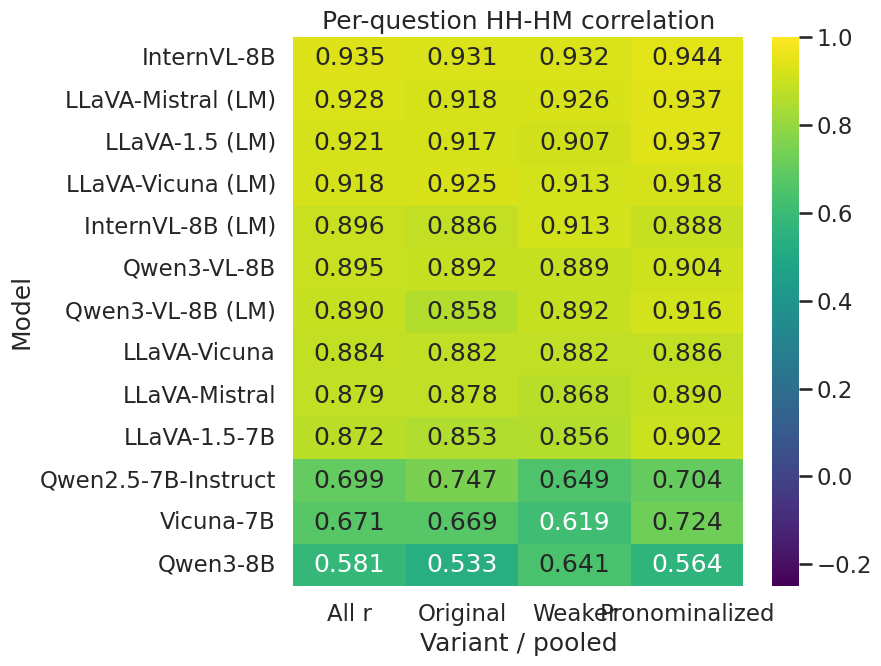

In [4]:
model_order = scatter['Model'].tolist()

scatter_heat = (
    scatter.set_index('Model')[['All r', 'Original', 'Weaker', 'Pronominalized']]
    .reindex(model_order)
)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(scatter_heat, annot=True, fmt='.3f', cmap='viridis', vmin=-0.25, vmax=1.0, ax=ax)
ax.set_title('Per-question HH-HM correlation')
ax.set_xlabel('Variant / pooled')
ax.set_ylabel('Model')
plt.tight_layout()
plt.show()

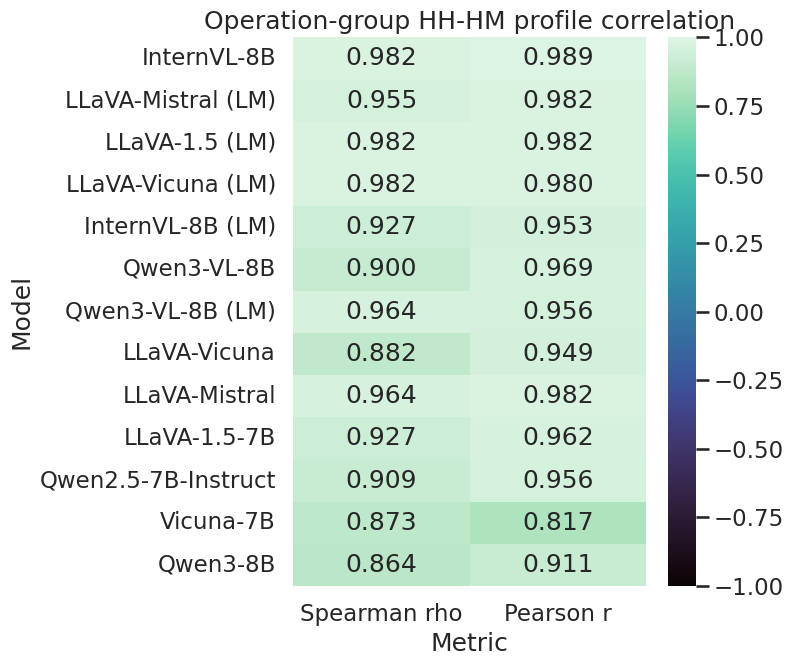

In [5]:
op_heat = op.set_index('Model')[['Spearman rho', 'Pearson r']].copy()
op_heat = op_heat.reindex([m for m in model_order if m in op_heat.index])

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(op_heat, annot=True, fmt='.3f', cmap='mako', vmin=-1.0, vmax=1.0, ax=ax)
ax.set_title('Operation-group HH-HM profile correlation')
ax.set_xlabel('Metric')
ax.set_ylabel('Model')
plt.tight_layout()
plt.show()

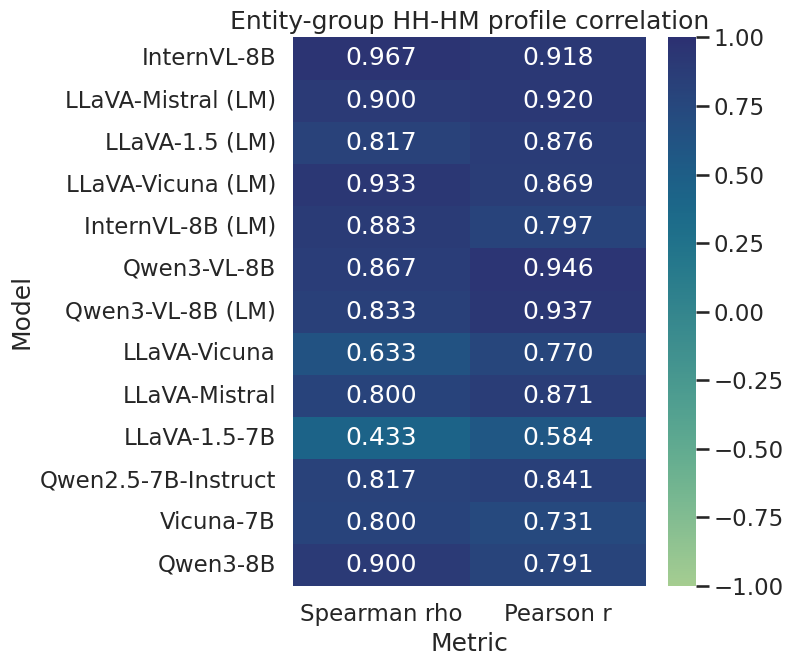

In [6]:
ent_heat = ent.set_index('Model')[['Spearman rho', 'Pearson r']].copy()
ent_heat = ent_heat.reindex([m for m in model_order if m in ent_heat.index])

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(ent_heat, annot=True, fmt='.3f', cmap='crest', vmin=-1.0, vmax=1.0, ax=ax)
ax.set_title('Entity-group HH-HM profile correlation')
ax.set_xlabel('Metric')
ax.set_ylabel('Model')
plt.tight_layout()
plt.show()